In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import StandardScaler


In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D3 in response_OUS
data = list(OUS_D3['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D3 with response_OUS
clinical_train = pd.merge(OUS_D3, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D3
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D3['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D3 in response_MAASTRO
data = list(MAASTRO_D3['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D3 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D3, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event
0,1,55,0,0,1,0,0,1,1,1,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,8.83,1.0
3,4,61,1,0,0,0,1,1,0,1,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,19.73,1.0
4,6,70,0,0,1,0,0,1,1,1,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,13.27,1.0
95,111,63,0,0,0,0,1,0,0,1,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 388)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]
lower, upper = np.percentile(y_MAASTRO['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 390)

# Standardization for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Saave the column and index 
X_columns = X.columns 
X_index = X.index

## Standardize the data but not the categorical columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

### Separate the categorical and non-categorical columns
X_categorical = X[categorical_columns]
X_numeric = X.drop(categorical_columns, axis=1)
X_numeric_columns = X_numeric.columns
X_numeric_index = X_numeric.index

### Standardize non-categorical and then concat with the categorical
scaler = StandardScaler()  
X_numeric_std = StandardScaler().fit_transform(X_numeric)
X_numeric_std = pd.DataFrame(X_numeric_std, columns=X_numeric_columns, index=X_numeric_index)
X_std = pd.concat([X_categorical, X_numeric_std], axis=1)

## Sort the order of the columns as it was in the clinical train 
X_std = X_std[original_X.columns]

## Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

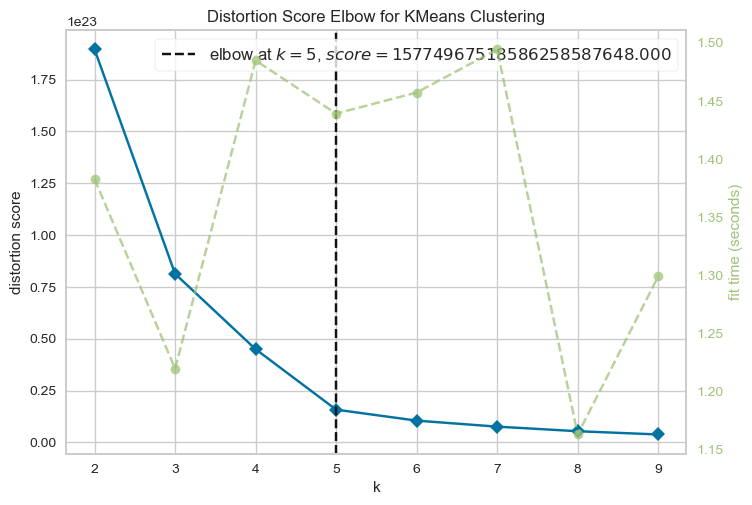

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [19]:
# How many clusters to form - 1. Using elbow method 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

In [20]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    variance = X_std[X_std.columns[cluster_labels==i]].var()

    # Find the most correlated column
    high_variance_column = variance.abs().idxmax()

    # Get the correlation coefficient of the most correlated column
    max_variance = variance.abs().max()

    print(i)
    print("Most correlated column:", high_variance_column)
    print("Correlation coefficient:", max_variance)
    print('\n')
    selected_features.append(high_variance_column)

KMeans(n_clusters=5)

0
Most correlated column: first_order_90Percentile_PET
Correlation coefficient: 1.0072463768115951


1
Most correlated column: gldm_DependenceNonUniformityNormalized_d_1_CT_b20
Correlation coefficient: 1.0072463768115951


2
Most correlated column: gldm_DependenceVariance_d_1_CT_b20
Correlation coefficient: 1.007246376811595


3
Most correlated column: glszm_HighGrayLevelZoneEmphasis_PET_c04
Correlation coefficient: 1.0072463768115953


4
Most correlated column: glcm_MCC_d_1_CT_b20
Correlation coefficient: 1.0072463768115953




In [21]:
# Selecting features in the DataFrame
X_fs_hv = X[selected_features]
X_new = X_fs_hv.copy()

X_MAASTRO_fs_hv = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_hv.copy()

# Standardization

In [22]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = StandardScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [23]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns

MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [24]:
X_new

,first_order_90Percentile_PET,gldm_DependenceNonUniformityNormalized_d_1_CT_b20,gldm_DependenceVariance_d_1_CT_b20,glszm_HighGrayLevelZoneEmphasis_PET_c04,glcm_MCC_d_1_CT_b20
0,12.976912,0.055238,32.025998,20.909091,0.817715
1,5.631130,0.050688,35.942044,17.583333,0.773956
2,6.963644,0.048612,33.209993,13.000000,0.810414
3,2.937064,0.077182,15.192779,18.818182,0.710132
4,5.652872,0.073116,19.325306,17.481481,0.567600
...,...,...,...,...,...
134,8.774738,0.052052,30.202196,15.000000,0.790123
135,6.606596,0.039528,47.087223,16.050000,0.826556
136,12.128900,0.039913,51.773108,16.000000,0.697606
137,7.277164,0.040037,46.650319,14.125000,0.753842


In [25]:
X_new_std

,first_order_90Percentile_PET,gldm_DependenceNonUniformityNormalized_d_1_CT_b20,gldm_DependenceVariance_d_1_CT_b20,glszm_HighGrayLevelZoneEmphasis_PET_c04,glcm_MCC_d_1_CT_b20
0,0.644250,0.771033,-1.120316,1.588680,0.482340
1,-0.947354,0.349452,-0.700377,0.719022,-0.140484
2,-0.658639,0.157028,-0.993349,-0.479481,0.378424
3,-1.531075,2.804650,-2.925433,1.041925,-1.048871
4,-0.942643,2.427799,-2.482280,0.692389,-3.077512
...,...,...,...,...,...
134,-0.266231,0.475848,-1.315892,0.043502,0.089627
135,-0.736001,-0.684808,0.494781,0.318068,0.608165
136,0.460512,-0.649065,0.997274,0.304994,-1.227159
137,-0.590709,-0.637641,0.447930,-0.185303,-0.426754


In [26]:
MAASTRO_new

,first_order_90Percentile_PET,gldm_DependenceNonUniformityNormalized_d_1_CT_b20,gldm_DependenceVariance_d_1_CT_b20,glszm_HighGrayLevelZoneEmphasis_PET_c04,glcm_MCC_d_1_CT_b20
0,14.076383,0.039893,57.342677,10.218750,0.734071
1,7.077812,0.044395,37.719160,12.055556,0.828113
2,11.123887,0.040159,48.627415,19.312500,0.778776
3,7.374829,0.061403,36.550528,15.611111,0.864230
4,8.358805,0.039451,51.353339,10.107143,0.842091
...,...,...,...,...,...
94,28.833381,0.040698,57.583609,16.684211,0.813111
95,11.134466,0.051691,57.203661,19.363636,0.857525
96,7.233497,0.039945,47.523358,10.333333,0.796506
97,11.935536,0.047941,43.231237,13.941176,0.836464


In [27]:
MAASTRO_new_std

,first_order_90Percentile_PET,gldm_DependenceNonUniformityNormalized_d_1_CT_b20,gldm_DependenceVariance_d_1_CT_b20,glszm_HighGrayLevelZoneEmphasis_PET_c04,glcm_MCC_d_1_CT_b20
0,0.882471,-0.651003,1.594529,-1.206755,-0.708161
1,-0.633903,-0.233801,-0.509807,-0.726446,0.630334
2,0.242757,-0.626272,0.659945,1.171185,-0.071881
3,-0.569548,1.342407,-0.635126,0.203303,1.144373
4,-0.356351,-0.691949,0.952260,-1.235939,0.829272
...,...,...,...,...,...
94,4.079857,-0.576406,1.620366,0.483909,0.416811
95,0.245049,0.442402,1.579622,1.184557,1.048942
96,-0.600170,-0.646098,0.541551,-1.176792,0.180468
97,0.418616,0.094875,0.081283,-0.233371,0.749184


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [28]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-19 14:35:40,479] A new study created in memory with name: no-name-0c94dfc5-5407-472d-9f73-9c6dd6b7ea27


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5657370517928287
Fold 2 C-index: 0.5503875968992248
Fold 3 C-index: 0.39574468085106385
Fold 4 C-index: 0.5703422053231939
Fold 5 C-index: 0.6266094420600858
[I 2024-04-19 14:35:41,079] Trial 0 finished with value: 0.5417641953852794 and parameters: {}. Best is trial 0 with value: 0.5417641953852794.


[I 2024-04-19 14:35:41,117] A new study created in memory with name: no-name-e32ef38a-9cab-4e61-87b7-d96bd7f78a54




* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5417641953852794], datetime_start=datetime.datetime(2024, 4, 19, 14, 35, 40, 712453), datetime_complete=datetime.datetime(2024, 4, 19, 14, 35, 41, 79031), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5417641953852794


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24179720531665896
Fold 2 IBS: 0.239735429667365
Fold 3 IBS: 0.2781865764438016
Fold 4 IBS: 0.27460544331064685
Fold 5 IBS: 0.21977242536571892
[I 2024-04-19 14:35:41,982] Trial 0 finished with value: 0.2508194160208383 and parameters: {}. Best is trial 0 with value: 0.2508194160208383.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2508194160208383], datetime_start=datetime.datetime(2024, 4, 19, 14, 35, 41, 298791), datetime_complete=datetime.datetime(2024, 4, 19, 14, 35, 41, 981820), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2508194160208383


In [29]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [30]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.542
train_ibs:  0.251


#### Test

In [31]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [32]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.523
IBS score: 0.239


In [33]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [34]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [35]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 14:35:42,445] A new study created in memory with name: no-name-c2c21e2f-e841-4f34-a82d-e8f11c849f75


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5418326693227091
Fold 2 C-index: 0.5968992248062015
Fold 3 C-index: 0.4829787234042553
Fold 4 C-index: 0.49049429657794674


[I 2024-04-19 14:35:42,867] A new study created in memory with name: no-name-f2f744ba-8009-4d57-9cb1-b9e79e4a368e


Fold 5 C-index: 0.592274678111588
[I 2024-04-19 14:35:42,854] Trial 0 finished with value: 0.5408959184445401 and parameters: {}. Best is trial 0 with value: 0.5408959184445401.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5408959184445401], datetime_start=datetime.datetime(2024, 4, 19, 14, 35, 42, 546415), datetime_complete=datetime.datetime(2024, 4, 19, 14, 35, 42, 853886), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5408959184445401


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24724709720966795
Fold 2 IBS: 0.23203988340287798
Fold 3 IBS: 0.2289818703467304
Fold 4 IBS: 0.24197477955640995
Fold 5 IBS: 0.22939559118500716
[I 2024-04-19 14:35:43,257] Trial 0 finished with value: 0.2359278443401387 and parameters: {}. Best is trial 0 with value: 0.2359278443401387.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2359278443401387], datetime_start=datetime.datetime(2024, 4, 19, 14, 35, 42, 919708), datetime_complete=datetime.datetime(2024, 4, 19, 14, 35, 43, 257718), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2359278443401387


In [36]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [37]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.541
train_ibs:  0.236


#### Test

In [38]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [39]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.507


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [40]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [41]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 14:35:43,681] A new study created in memory with name: no-name-f6358223-bffb-48b3-9ede-80b8aa8693bc


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-19 14:35:44,023] A new study created in memory with name: no-name-89ec446d-ea6b-470e-8b04-0f02eb0002fa


Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.5930232558139535
Fold 3 C-index: 0.39574468085106385
Fold 4 C-index: 0.49049429657794674
Fold 5 C-index: 0.592274678111588
[I 2024-04-19 14:35:44,011] Trial 0 finished with value: 0.5214786970119463 and parameters: {}. Best is trial 0 with value: 0.5214786970119463.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5214786970119463], datetime_start=datetime.datetime(2024, 4, 19, 14, 35, 43, 730438), datetime_complete=datetime.datetime(2024, 4, 19, 14, 35, 44, 11332), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5214786970119463


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2432766247398099
Fold 2 IBS: 0.23163621559506545
Fold 3 IBS: 0.27811191346447023
Fold 4 IBS: 0.24877371786887684
Fold 5 IBS: 0.22693838681381928
[I 2024-04-19 14:35:44,704] Trial 0 finished with value: 0.24574737169640834 and parameters: {}. Best is trial 0 with value: 0.24574737169640834.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.24574737169640834], datetime_start=datetime.datetime(2024, 4, 19, 14, 35, 44, 70946), datetime_complete=datetime.datetime(2024, 4, 19, 14, 35, 44, 703926), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.24574737169640834


In [42]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [43]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.521
train_ibs:  0.246


#### Test

In [44]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [45]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.503


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.23


In [46]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [47]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 14:35:45,457] A new study created in memory with name: no-name-52be01ea-3229-4e25-a705-803b6b14de34


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.5930232558139535
Fold 3 C-index: 0.39574468085106385
Fold 4 C-index: 0.4866920152091255
Fold 5 C-index: 0.592274678111588
[I 2024-04-19 14:35:46,126] Trial 0 finished with value: 0.5207182407381821 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.5207182407381821.
Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.6007751937984496
Fold 3 C-index: 0.39574468085106385
Fold 4 C-index: 0.4828897338403042
Fold 5 C-index: 0.592274678111588
[I 2024-04-19 14:35:46,720] Trial 1 finished with value: 0.5215081720613169 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.5215081720613169.
Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.6007751937984496
Fold 3 C-index: 0.46808510638297873
Fold 4 C-index: 0.4828897338403042
Fold 5 C-index: 0.592274678111588
[I 2024-04-19 14:35:47,541] Trial 2 finished with value: 0.5359762571676999 and parameters: {'l1_ratio': 0.22692876841884668}.

Fold 2 C-index: 0.6007751937984496
Fold 3 C-index: 0.4851063829787234
Fold 4 C-index: 0.4828897338403042
Fold 5 C-index: 0.592274678111588
[I 2024-04-19 14:35:56,961] Trial 24 finished with value: 0.5393805124868489 and parameters: {'l1_ratio': 0.07555835218569971}. Best is trial 11 with value: 0.5408428552604657.
Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.6046511627906976
Fold 3 C-index: 0.4765957446808511
Fold 4 C-index: 0.4828897338403042
Fold 5 C-index: 0.592274678111588
[I 2024-04-19 14:35:57,071] Trial 25 finished with value: 0.5384535786257241 and parameters: {'l1_ratio': 0.16728106154199432}. Best is trial 11 with value: 0.5408428552604657.
Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.5930232558139535
Fold 3 C-index: 0.39574468085106385
Fold 4 C-index: 0.49049429657794674
Fold 5 C-index: 0.592274678111588
[I 2024-04-19 14:35:57,177] Trial 26 finished with value: 0.5214786970119463 and parameters: {'l1_ratio': 0.8401513352750697}. Best is trial 11 with value: 0

Fold 2 C-index: 0.5968992248062015
Fold 3 C-index: 0.39574468085106385
Fold 4 C-index: 0.4866920152091255
Fold 5 C-index: 0.592274678111588
[I 2024-04-19 14:36:04,625] Trial 48 finished with value: 0.5214934345366317 and parameters: {'l1_ratio': 0.5683872043393509}. Best is trial 40 with value: 0.5422415027946896.
Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.5968992248062015
Fold 3 C-index: 0.39574468085106385
Fold 4 C-index: 0.4828897338403042
Fold 5 C-index: 0.592274678111588
[I 2024-04-19 14:36:04,925] Trial 49 finished with value: 0.5207329782628674 and parameters: {'l1_ratio': 0.4477016529538363}. Best is trial 40 with value: 0.5422415027946896.
Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.6007751937984496
Fold 3 C-index: 0.39574468085106385
Fold 4 C-index: 0.4828897338403042
Fold 5 C-index: 0.592274678111588
[I 2024-04-19 14:36:05,584] Trial 50 finished with value: 0.5215081720613169 and parameters: {'l1_ratio': 0.31297686520002327}. Best is trial 40 with value: 0

...

Fold 1 IBS: 0.2434628693912835
Fold 2 IBS: 0.23158259196207037
Fold 3 IBS: 0.2780615580035565
Fold 4 IBS: 0.24850911560624814
Fold 5 IBS: 0.22707231254522636
[I 2024-04-19 14:36:26,381] Trial 0 finished with value: 0.24573768950167696 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.24573768950167696.
Fold 1 IBS: 0.24416306939968177
Fold 2 IBS: 0.23148742986586157
Fold 3 IBS: 0.277916507706482
Fold 4 IBS: 0.24747153157511842
Fold 5 IBS: 0.22754766367287116
[I 2024-04-19 14:36:26,923] Trial 1 finished with value: 0.24571724044400298 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.24571724044400298.
Fold 1 IBS: 0.24440049912513265
Fold 2 IBS: 0.231483258204597
Fold 3 IBS: 0.23336324391895122
Fold 4 IBS: 0.24710384603426772
Fold 5 IBS: 0.2277012993279319
[I 2024-04-19 14:36:27,259] Trial 2 finished with value: 0.23681042932217608 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.2368104293221760

Fold 1 IBS: 0.2456580997667491
Fold 2 IBS: 0.23161431918728395
Fold 3 IBS: 0.23061888538106953
Fold 4 IBS: 0.24500908337696772
Fold 5 IBS: 0.22847502637697922
[I 2024-04-19 14:36:37,457] Trial 25 finished with value: 0.2362750828178099 and parameters: {'l1_ratio': 0.07330522822697523}. Best is trial 13 with value: 0.23596339507974107.
Fold 1 IBS: 0.24451998363537006
Fold 2 IBS: 0.2314853352994791
Fold 3 IBS: 0.2330001892761846
Fold 4 IBS: 0.24691563675832828
Fold 5 IBS: 0.22777749358787755
[I 2024-04-19 14:36:38,051] Trial 26 finished with value: 0.23673972771144794 and parameters: {'l1_ratio': 0.20309774849254153}. Best is trial 13 with value: 0.23596339507974107.
Fold 1 IBS: 0.24591205859086546
Fold 2 IBS: 0.23166516481137295
Fold 3 IBS: 0.23026493343984183
Fold 4 IBS: 0.24455392371461795
Fold 5 IBS: 0.22862538229967472
[I 2024-04-19 14:36:38,780] Trial 27 finished with value: 0.23620429257127457 and parameters: {'l1_ratio': 0.056847137315710346}. Best is trial 13 with value: 0.23596

Fold 5 IBS: 0.22728304692675946
[I 2024-04-19 14:36:52,017] Trial 49 finished with value: 0.24572763243571538 and parameters: {'l1_ratio': 0.4477016529538363}. Best is trial 46 with value: 0.23592887323129003.
Fold 1 IBS: 0.24538396042175448
Fold 2 IBS: 0.2315676005810277
Fold 3 IBS: 0.23105809106942077
Fold 4 IBS: 0.24548790047605076
Fold 5 IBS: 0.22831088253657122
[I 2024-04-19 14:36:52,434] Trial 50 finished with value: 0.236361687016965 and parameters: {'l1_ratio': 0.09451319327765746}. Best is trial 46 with value: 0.23592887323129003.
Fold 1 IBS: 0.2470599618996269
Fold 2 IBS: 0.23197611213400537
Fold 3 IBS: 0.22911938806860913
Fold 4 IBS: 0.24242272278220575
Fold 5 IBS: 0.22928784717886963
[I 2024-04-19 14:36:52,890] Trial 51 finished with value: 0.23597320641266334 and parameters: {'l1_ratio': 0.006012844952470507}. Best is trial 46 with value: 0.23592887323129003.
Fold 1 IBS: 0.24715542385986602
Fold 2 IBS: 0.2320079902509899
Fold 3 IBS: 0.22904785072696157
Fold 4 IBS: 0.242200

Fold 1 IBS: 0.247185113396254
Fold 2 IBS: 0.23201826391291333
Fold 3 IBS: 0.22902615310082372
Fold 4 IBS: 0.24212819212302442
Fold 5 IBS: 0.2293599127062175
[I 2024-04-19 14:37:02,380] Trial 74 finished with value: 0.23594352704784657 and parameters: {'l1_ratio': 0.001939745630995339}. Best is trial 63 with value: 0.23592874831047944.
Fold 1 IBS: 0.24628205194633365
Fold 2 IBS: 0.2317503243825578
Fold 3 IBS: 0.22982874415631407
Fold 4 IBS: 0.2439128079517164
Fold 5 IBS: 0.22883939039945717
[I 2024-04-19 14:37:02,780] Trial 75 finished with value: 0.23612266376727584 and parameters: {'l1_ratio': 0.03717982365573151}. Best is trial 63 with value: 0.23592874831047944.
Fold 1 IBS: 0.24568723319820304
Fold 2 IBS: 0.2316197922179195
Fold 3 IBS: 0.23057587490864248
Fold 4 IBS: 0.24495743899705366
Fold 5 IBS: 0.22849235381373403
[I 2024-04-19 14:37:03,189] Trial 76 finished with value: 0.23626653862711056 and parameters: {'l1_ratio': 0.0712774675720134}. Best is trial 63 with value: 0.23592874

Fold 4 IBS: 0.2420702759637467
Fold 5 IBS: 0.22937347201702715
[I 2024-04-19 14:37:13,746] Trial 98 finished with value: 0.23593760659039695 and parameters: {'l1_ratio': 0.0011967521668007717}. Best is trial 63 with value: 0.23592874831047944.
Fold 1 IBS: 0.24508215796275973
Fold 2 IBS: 0.23152681306494688
Fold 3 IBS: 0.23162532362016833
Fold 4 IBS: 0.24600036573234604
Fold 5 IBS: 0.22812762713320617
[I 2024-04-19 14:37:14,064] Trial 99 finished with value: 0.23647245750268545 and parameters: {'l1_ratio': 0.12345871196024548}. Best is trial 63 with value: 0.23592874831047944.


* Best trial for IBS: 
 FrozenTrial(number=63, state=TrialState.COMPLETE, values=[0.23592874831047944], datetime_start=datetime.datetime(2024, 4, 19, 14, 36, 57, 442063), datetime_complete=datetime.datetime(2024, 4, 19, 14, 36, 57, 828881), params={'l1_ratio': 0.00010944776235348343}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0

In [48]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [49]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.543
train_ibs:  0.236


#### Test

In [50]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [51]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.037672384612766875)

test_cindex : 0.503


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.00010944776235348343)

test_ibs:  0.229


In [52]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [53]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-19 14:37:14,685] A new study created in memory with name: no-name-d666e130-1d46-4d99-bf2a-476c4bbcfc9f


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.4860557768924303
Fold 2 C-index: 0.5387596899224806
Fold 3 C-index: 0.43829787234042555
Fold 4 C-index: 0.41064638783269963
Fold 5 C-index: 0.41630901287553645
[I 2024-04-19 14:37:23,044] Trial 0 finished with value: 0.45801374797271455 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.45801374797271455.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.46124031007751937
Fold 3 C-index: 0.425531914893617
Fold 4 C-index: 0.5019011406844106
Fold 5 C-index: 0.4034334763948498
[I 2024-04-19 14:37:32,547] Trial 1 finished with value: 0.4428835198045017 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.752009792374

Fold 1 C-index: 0.45219123505976094
Fold 2 C-index: 0.6569767441860465
Fold 3 C-index: 0.6234042553191489
Fold 4 C-index: 0.5760456273764258
Fold 5 C-index: 0.6523605150214592
[I 2024-04-19 14:38:55,581] Trial 16 finished with value: 0.5921956753925682 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 15, 'min_samples_leaf': 1, 'max_depth': 20, 'n_estimators': 5, 'oob_score': False, 'max_samples': 0.7660641189637482, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.20474687064294764, 'warm_start': True}. Best is trial 15 with value: 0.5995055779321861.
Fold 1 C-index: 0.5298804780876494
Fold 2 C-index: 0.6569767441860465
Fold 3 C-index: 0.6446808510638298
Fold 4 C-index: 0.49429657794676807
Fold 5 C-index: 0.6094420600858369
[I 2024-04-19 14:38:55,799] Trial 17 finished with value: 0.5870553422740261 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 16, 'min_samples_leaf': 1, 'max_depth': 18, 'n_estimators': 4, 'oob_score': False, 'max_samples': 0.77834046988366

Fold 1 C-index: 0.41434262948207173
Fold 2 C-index: 0.8527131782945736
Fold 3 C-index: 0.851063829787234
Fold 4 C-index: 0.8022813688212928
Fold 5 C-index: 0.8583690987124464
[I 2024-04-19 14:39:30,747] Trial 31 finished with value: 0.7557540210195237 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 17, 'min_samples_leaf': 3, 'max_depth': 13, 'n_estimators': 334, 'oob_score': True, 'max_samples': 0.6605997269280341, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.009638498587672623, 'warm_start': True}. Best is trial 30 with value: 0.762827388795738.
Fold 1 C-index: 0.42231075697211157
Fold 2 C-index: 0.8527131782945736
Fold 3 C-index: 0.8553191489361702
Fold 4 C-index: 0.7908745247148289
Fold 5 C-index: 0.8540772532188842
[I 2024-04-19 14:39:34,947] Trial 32 finished with value: 0.7550589724273137 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 16, 'min_samples_leaf': 3, 'max_depth': 13, 'n_estimators': 333, 'oob_score': True, 'max_samples': 0.673489822483

...

Fold 1 IBS: 0.246386460438482
Fold 2 IBS: 0.23218899742898796
Fold 3 IBS: 0.22946758410602397
Fold 4 IBS: 0.24118772219117468
Fold 5 IBS: 0.2303071920630508
[I 2024-04-19 14:45:02,011] Trial 32 finished with value: 0.2359075912455439 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 8, 'min_samples_leaf': 4, 'max_depth': 14, 'n_estimators': 175, 'oob_score': True, 'max_samples': 0.20444340416617043, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.19558060234973634}. Best is trial 27 with value: 0.23583547084615547.
Fold 1 IBS: 0.24684478929600995
Fold 2 IBS: 0.2322329224950302
Fold 3 IBS: 0.23005427140610996
Fold 4 IBS: 0.2412308304074783
Fold 5 IBS: 0.2301271605653773
[I 2024-04-19 14:45:06,371] Trial 33 finished with value: 0.23609799483400112 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 7, 'min_samples_leaf': 2, 'max_depth': 13, 'n_estimators': 235, 'oob_score': True, 'max_samples': 0.23980153995474307, 'max_features': 'log2', 'min_weight_fraction_leaf

Fold 5 IBS: 0.22978676956550373
[I 2024-04-19 14:46:04,996] Trial 47 finished with value: 0.23575678560731528 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 16, 'min_samples_leaf': 3, 'max_depth': 9, 'n_estimators': 160, 'oob_score': True, 'max_samples': 0.13434415907111946, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.10612603041708193}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24757897353687755
Fold 2 IBS: 0.2320725752850252
Fold 3 IBS: 0.2299544780683508
Fold 4 IBS: 0.24154478404388094
Fold 5 IBS: 0.23016145399352744
[I 2024-04-19 14:46:07,265] Trial 48 finished with value: 0.2362624529855324 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 18, 'min_samples_leaf': 7, 'max_depth': 9, 'n_estimators': 86, 'oob_score': True, 'max_samples': 0.12964207163685623, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.10203918387448863}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24671151151924972
Fold 2 IBS: 0.2321

Fold 1 IBS: 0.24631928839139375
Fold 2 IBS: 0.23211332325251055
Fold 3 IBS: 0.22987340393724426
Fold 4 IBS: 0.24110794902474542
Fold 5 IBS: 0.2296571564179856
[I 2024-04-19 14:46:53,889] Trial 63 finished with value: 0.2358142242047759 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 8, 'n_estimators': 150, 'oob_score': True, 'max_samples': 0.10056089265752739, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.026471209866795242}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24648722835656947
Fold 2 IBS: 0.23206092276817514
Fold 3 IBS: 0.22928811947466984
Fold 4 IBS: 0.24128731957110403
Fold 5 IBS: 0.22992351169818162
[I 2024-04-19 14:46:56,177] Trial 64 finished with value: 0.23580942037374003 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 15, 'min_samples_leaf': 4, 'max_depth': 8, 'n_estimators': 104, 'oob_score': True, 'max_samples': 0.17392096150604247, 'max_features': 'sqrt', 'min_weight_fractio

Fold 5 IBS: 0.2724760038612252
[I 2024-04-19 14:47:40,830] Trial 78 finished with value: 0.26038359573012937 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 11, 'n_estimators': 171, 'oob_score': True, 'max_samples': 0.9147835512625551, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.13257772422273512}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24630596960013934
Fold 2 IBS: 0.23202892604980208
Fold 3 IBS: 0.23058361904315297
Fold 4 IBS: 0.24129573617042252
Fold 5 IBS: 0.2301768553877985
[I 2024-04-19 14:47:42,251] Trial 79 finished with value: 0.2360782212502631 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 11, 'min_samples_leaf': 1, 'max_depth': 12, 'n_estimators': 37, 'oob_score': True, 'max_samples': 0.2189744006895358, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.17152888523323856}. Best is trial 46 with value: 0.23574917305158732.
Fold 1 IBS: 0.24642825384745612
Fold 2 IBS: 0.2320

Fold 1 IBS: 0.24603980142682666
Fold 2 IBS: 0.23212293756683253
Fold 3 IBS: 0.22980177266109972
Fold 4 IBS: 0.24117019375096946
Fold 5 IBS: 0.23000323031974987
[I 2024-04-19 14:48:45,595] Trial 94 finished with value: 0.23582758714509566 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 9, 'min_samples_leaf': 4, 'max_depth': 4, 'n_estimators': 186, 'oob_score': True, 'max_samples': 0.15211446012016716, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.1336981908011637}. Best is trial 84 with value: 0.23572114547332967.
Fold 1 IBS: 0.24609144860992238
Fold 2 IBS: 0.23210462726436726
Fold 3 IBS: 0.23027168009436597
Fold 4 IBS: 0.24100241364516664
Fold 5 IBS: 0.2300638162943246
[I 2024-04-19 14:48:55,557] Trial 95 finished with value: 0.23590679718162938 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 11, 'min_samples_leaf': 13, 'max_depth': 3, 'n_estimators': 489, 'oob_score': True, 'max_samples': 0.12627955102410032, 'max_features': 'auto', 'min_weight_fraction

In [54]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [55]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.805
train_ibs:  0.236


#### Test

In [56]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [57]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=8, max_features=None, max_leaf_nodes=13,
                     max_samples=0.9962760623593794, min_samples_split=13,
                     min_weight_fraction_leaf=0.02002284312244475,
                     n_estimators=362, random_state=123, warm_start=True)

test_cindex:  0.519


RandomSurvivalForest(max_depth=3, max_features='auto', max_leaf_nodes=11,
                     max_samples=0.1369774849788948, min_samples_leaf=2,
                     min_samples_split=20,
                     min_weight_fraction_leaf=0.07082006896114468,
                     n_estimators=186, oob_score=True, random_state=123)

test_ibs:  0.23


In [58]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [59]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 14:49:14,496] A new study created in memory with name: no-name-6fc2b35b-b974-4c5d-bce7-7753011ca6e2


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.47808764940239046
Fold 2 C-index: 0.7403100775193798
Fold 3 C-index: 0.6638297872340425
Fold 4 C-index: 0.6501901140684411
Fold 5 C-index: 0.703862660944206
[I 2024-04-19 14:49:16,516] Trial 0 finished with value: 0.647256057833692 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.647256057833692.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 14:49:20,961] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531}.

Fold 1 C-index: 0.5099601593625498
Fold 2 C-index: 0.6356589147286822
Fold 3 C-index: 0.6042553191489362
Fold 4 C-index: 0.5019011406844106
Fold 5 C-index: 0.575107296137339
[I 2024-04-19 14:50:09,467] Trial 16 finished with value: 0.5653765660123835 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.8750346354626457, 'min_weight_fraction_leaf': 0.4093818399278544}. Best is trial 12 with value: 0.6548934889696214.
Fold 1 C-index: 0.5418326693227091
Fold 2 C-index: 0.6627906976744186
Fold 3 C-index: 0.6297872340425532
Fold 4 C-index: 0.5741444866920152
Fold 5 C-index: 0.5493562231759657
[I 2024-04-19 14:50:10,926] Trial 17 finished with value: 0.5915822621815323 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 10, 'min_samples_leaf': 8, 'max_depth': 12, 'n_estimators': 318, 'oob_score': False, 'warm_start': True, 'max_featu

Fold 1 C-index: 0.47410358565737054
Fold 2 C-index: 0.7674418604651163
Fold 3 C-index: 0.6680851063829787
Fold 4 C-index: 0.6730038022813688
Fold 5 C-index: 0.6995708154506438
[I 2024-04-19 14:50:47,115] Trial 31 finished with value: 0.6564410340474957 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 5, 'min_samples_leaf': 6, 'max_depth': 11, 'n_estimators': 399, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.6266312071772465, 'min_weight_fraction_leaf': 0.03146229039344864}. Best is trial 23 with value: 0.6824097101916118.
Fold 1 C-index: 0.4860557768924303
Fold 2 C-index: 0.7403100775193798
Fold 3 C-index: 0.6851063829787234
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.7381974248927039
[I 2024-04-19 14:50:49,352] Trial 32 finished with value: 0.6690974305555069 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 395, 'oob_score': False, 'warm_start': True, 'max_feat

...

Fold 1 IBS: 0.2466509090859412
Fold 2 IBS: 0.23214878301411424
Fold 3 IBS: 0.2293161545437167
Fold 4 IBS: 0.2416001168061908
Fold 5 IBS: 0.23029389935280453
[I 2024-04-19 14:57:34,430] Trial 30 finished with value: 0.2360019725605535 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 10, 'min_samples_leaf': 9, 'max_depth': 11, 'n_estimators': 176, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.6685390299837802, 'min_weight_fraction_leaf': 0.39443765410475895}. Best is trial 1 with value: 0.2359075685671228.
Fold 1 IBS: 0.24658437242309666
Fold 2 IBS: 0.23217269485057873
Fold 3 IBS: 0.22938349245574668
Fold 4 IBS: 0.24142526486365426
Fold 5 IBS: 0.23026356293423877
[I 2024-04-19 14:57:38,937] Trial 31 finished with value: 0.23596587750546302 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 10, 'min_samples_leaf': 12, 'max_depth': 8, 'n_estimators': 195, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.

Fold 1 IBS: 0.2448356220288334
Fold 2 IBS: 0.2311622960793092
Fold 3 IBS: 0.23053223837342157
Fold 4 IBS: 0.24284914166593052
Fold 5 IBS: 0.23499123389122342
[I 2024-04-19 14:58:24,274] Trial 45 finished with value: 0.23687410640774362 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 20, 'min_samples_leaf': 16, 'max_depth': 13, 'n_estimators': 70, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.575340118469, 'min_weight_fraction_leaf': 0.24054404838650845}. Best is trial 1 with value: 0.2359075685671228.
Fold 1 IBS: 0.24659359240198095
Fold 2 IBS: 0.23209868139989004
Fold 3 IBS: 0.2295723172335429
Fold 4 IBS: 0.2413972803272666
Fold 5 IBS: 0.22982204193455305
[I 2024-04-19 14:58:27,215] Trial 46 finished with value: 0.2358967826594467 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 15, 'min_samples_leaf': 16, 'max_depth': 15, 'n_estimators': 98, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.478097375193

Fold 1 IBS: 0.24685013557318541
Fold 2 IBS: 0.23221134941984206
Fold 3 IBS: 0.2295076065158497
Fold 4 IBS: 0.2412304994301724
Fold 5 IBS: 0.23008031288998662
[I 2024-04-19 14:59:12,544] Trial 60 finished with value: 0.23597598076580723 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 18, 'min_samples_leaf': 19, 'max_depth': 20, 'n_estimators': 139, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.2992752088637204, 'min_weight_fraction_leaf': 0.32324739861295254}. Best is trial 53 with value: 0.2358899168129503.
Fold 1 IBS: 0.2465225254551419
Fold 2 IBS: 0.2320932394483033
Fold 3 IBS: 0.22978546868639518
Fold 4 IBS: 0.24145796823242194
Fold 5 IBS: 0.22994397966370472
[I 2024-04-19 14:59:13,950] Trial 61 finished with value: 0.23596063629719338 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 18, 'min_samples_leaf': 18, 'max_depth': 16, 'n_estimators': 76, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.4462459212

Fold 1 IBS: 0.24644138753483755
Fold 2 IBS: 0.2320799051943486
Fold 3 IBS: 0.22963996799405775
Fold 4 IBS: 0.2413677053674444
Fold 5 IBS: 0.2298577227867459
[I 2024-04-19 14:59:41,987] Trial 75 finished with value: 0.23587733777548686 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 14, 'min_samples_leaf': 19, 'max_depth': 20, 'n_estimators': 81, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.5285099807166639, 'min_weight_fraction_leaf': 0.44997382624231097}. Best is trial 71 with value: 0.23583427784638097.
Fold 1 IBS: 0.24670526087208394
Fold 2 IBS: 0.2321201972105975
Fold 3 IBS: 0.2297857007771967
Fold 4 IBS: 0.24154417969608755
Fold 5 IBS: 0.22996290626510735
[I 2024-04-19 14:59:43,592] Trial 76 finished with value: 0.2360236489642146 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 14, 'min_samples_leaf': 19, 'max_depth': 20, 'n_estimators': 52, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.505272

Fold 1 IBS: 0.24706303965767867
Fold 2 IBS: 0.2320938767584291
Fold 3 IBS: 0.2297916235083027
Fold 4 IBS: 0.24144511052633214
Fold 5 IBS: 0.23001031267889704
[I 2024-04-19 15:00:04,607] Trial 90 finished with value: 0.23608079262592793 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 4, 'min_samples_leaf': 18, 'max_depth': 20, 'n_estimators': 71, 'oob_score': False, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.4376269527464442, 'min_weight_fraction_leaf': 0.4535335344988851}. Best is trial 71 with value: 0.23583427784638097.
Fold 1 IBS: 0.24653610254230626
Fold 2 IBS: 0.23212818356827855
Fold 3 IBS: 0.22959735964110284
Fold 4 IBS: 0.24144558914211794
Fold 5 IBS: 0.2298682973599372
[I 2024-04-19 15:00:06,770] Trial 91 finished with value: 0.23591510645074854 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 15, 'min_samples_leaf': 20, 'max_depth': 19, 'n_estimators': 90, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.473457

In [60]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [61]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.732
train_ibs:  0.236


#### Test

In [62]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [63]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=8, max_features=None, max_leaf_nodes=20,
                   max_samples=0.9176978018176684, min_samples_leaf=2,
                   min_samples_split=14,
                   min_weight_fraction_leaf=0.024818394323885353,
                   n_estimators=189, oob_score=True, random_state=123,
                   warm_start=True)

C-index score: 0.559


ExtraSurvivalTrees(max_depth=18, max_features=None, max_leaf_nodes=14,
                   max_samples=0.4907684884375094, min_samples_leaf=20,
                   min_weight_fraction_leaf=0.4437338994544069, n_estimators=79,
                   random_state=123, warm_start=True)

IBS: 0.229


In [64]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [65]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-19 15:00:26,084] A new study created in memory with name: no-name-2d7827cd-2603-4238-b92f-2aaa682aac8d


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 15:01:02,009] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 15:01:22,513] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 15:08:10,910] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.402356635584068, 'learning_rate': 0.04320515007344335, 'dropout_rate': 0.4821375662037144, 'n_estimators': 338, 'criterion': 'friedman_mse', 'ccp_alpha': 5.782673919726945, 'min_weight_fraction_leaf': 0.3780093996731174, 'max_features': 1, 'min_impurity_decrease': 4.1224286247713165e-05, 'validation_fraction': 0.3705130702856921, 'min_samples_split': 16, 'max_leaf_nodes': 12, 'min_samples_leaf': 16, 'max_depth': 14}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 15:09:02,081] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.8084735022381804, 'learning_rate': 0.051554368700984315, 'dropout_rate': 0.7600297296847041, 'n_estimators': 485, 'criterion': 'friedman_mse', 'ccp_alpha': 1.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 15:14:52,807] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.7290419373338021, 'learning_rate': 0.008509588429086327, 'dropout_rate': 0.8441717101825217, 'n_estimators': 96, 'criterion': 'squared_error', 'ccp_alpha': 4.233740780727753, 'min_weight_fraction_leaf': 0.32029463020494575, 'max_features': 1, 'min_impurity_decrease': 3.23815069163876e-06, 'validation_fraction': 0.3886651085109431, 'min_samples_split': 6, 'max_leaf_nodes': 16, 'min_samples_leaf': 14, 'max_depth': 6}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-19 15:15:01,634] Trial 27 finished with value: 0.5 and parameters: {'subsample': 0.835623033509183, 'learning_rate': 0.0441170168532854, 'dropout_rate': 0.661659879615144, 'n_estimators': 170, 'criterion': 'friedman_mse', 'ccp_alpha': 5.46231

...

Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-19 16:04:37,297] Trial 45 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6347814711411004, 'learning_rate': 0.024918730390022577, 'dropout_rate': 0.4346567206287487, 'n_estimators': 71, 'criterion': 'friedman_mse', 'ccp_alpha': 9.50847856451098, 'min_weight_fraction_leaf': 0.204461577134346, 'max_features': 'auto', 'min_impurity_decrease': 7.287535049264176e-05, 'validation_fraction': 0.296384154065476, 'min_samples_split': 10, 'max_leaf_nodes': 11, 'min_samples_leaf': 5, 'max_depth': 9}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-19 16:04:42,833] Trial 46 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.8011995442645217, 'learni

Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-19 16:07:37,956] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.2887765610954624, 'learning_rate': 0.09459281124929597, 'dropout_rate': 0.4973870333170236, 'n_estimators': 343, 'criterion': 'friedman_mse', 'ccp_alpha': 2.3090586149455574, 'min_weight_fraction_leaf': 0.16870893777683815, 'max_features': None, 'min_impurity_decrease': 9.555769670116001e-07, 'validation_fraction': 0.8832333189890804, 'min_samples_split': 13, 'max_leaf_nodes': 12, 'min_samples_leaf': 8, 'max_depth': 12}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.22939559304809248
[I 2024-04-19 16:07:56,629] Trial 57 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7386655194472563, 'learning_rate': 0.08121117574322781, 'dropout_rate': 0.7097006096

Fold 5 IBS: 0.2293955930480925
[I 2024-04-19 16:10:24,179] Trial 67 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6828521170655483, 'learning_rate': 0.022258646319799062, 'dropout_rate': 0.6010596795994926, 'n_estimators': 87, 'criterion': 'squared_error', 'ccp_alpha': 5.4909073156880295, 'min_weight_fraction_leaf': 0.1860826779096332, 'max_features': 'auto', 'min_impurity_decrease': 0.00019344127251504632, 'validation_fraction': 0.3679720810813184, 'min_samples_split': 9, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 4}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-19 16:10:45,739] Trial 68 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.640231117985754, 'learning_rate': 0.0690549249219706, 'dropout_rate': 0.7519380649315037, 'n_estimators': 327, 'crit

Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-19 16:13:02,064] Trial 79 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5239417471386933, 'learning_rate': 0.020324753076534783, 'dropout_rate': 0.25505231881333934, 'n_estimators': 219, 'criterion': 'squared_error', 'ccp_alpha': 8.06685235564664, 'min_weight_fraction_leaf': 0.10889477607680587, 'max_features': None, 'min_impurity_decrease': 2.113599021609697e-05, 'validation_fraction': 0.19421333161738485, 'min_samples_split': 9, 'max_leaf_nodes': 11, 'min_samples_leaf': 3, 'max_depth': 10}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927107
Fold 5 IBS: 0.2293955930480925
[I 2024-04-19 16:13:24,370] Trial 80 finished with value: 0.2359278435123307 and parameters: {'sub

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-19 16:16:59,646] Trial 90 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7495496502041824, 'learning_rate': 0.0581528234960663, 'dropout_rate': 0.7348956640088382, 'n_estimators': 384, 'criterion': 'friedman_mse', 'ccp_alpha': 3.5249398640258107, 'min_weight_fraction_leaf': 0.3046819488123618, 'max_features': 'log2', 'min_impurity_decrease': 6.057529663822337e-06, 'validation_fraction': 0.2789829481077005, 'min_samples_split': 4, 'max_leaf_nodes': 5, 'min_samples_leaf': 18, 'max_depth': 15}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658996
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-19 16:17:01,138] Trial 91 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5619495945045616, 'learning_rate': 0.06700515143766485

In [66]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [67]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.5
train_ibs:  0.236


#### Test

In [68]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [69]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=9.807641983846155,
                                 dropout_rate=0.3041663082077828,
                                 learning_rate=0.02932779416008757,
                                 max_depth=11, max_leaf_nodes=5,
                                 min_impurity_decrease=2.4449249473284515e-05,
                                 min_samples_leaf=11, min_samples_split=5,
                                 min_weight_fraction_leaf=0.34241486929243165,
                                 n_estimators=276, random_state=123,
                                 subsample=0.7268222670380755,
                                 validation_fraction=0.7379954057320357)

C-index score: 0.5


GradientBoostingSurvivalAnalysis(ccp_alpha=7.636828414433382,
                                 dropout_rate=0.6624131518860399,
                                 learning_rate=0.059007718703659076,
                                 max_depth=14, max_leaf_nodes=5,
                                 min_impurity_decrease=1.2496121527731156e-07,
                                 min_samples_leaf=4, min_samples_split=12,
                                 min_weight_fraction_leaf=0.121833187268437,
                                 n_estimators=338, random_state=123,
                                 subsample=0.7023824046660451,
                                 validation_fraction=0.5944318794450425)

IBS: 0.229


In [70]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [71]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = StandardScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-19 16:19:59,578] A new study created in memory with name: no-name-c25d3d27-40f3-403a-8eda-26198dd4af73


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5378486055776892
Fold 2 C-index: 0.6085271317829457
Fold 3 C-index: 0.5063829787234042
Fold 4 C-index: 0.49429657794676807
Fold 5 C-index: 0.5879828326180258
[I 2024-04-19 16:20:00,887] Trial 0 finished with value: 0.5470076253297667 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.5470076253297667.
Fold 1 C-index: 0.5378486055776892
Fold 2 C-index: 0.6046511627906976
Fold 3 C-index: 0.5106382978723404
Fold 4 C-index: 0.4714828897338403
Fold 5 C-index: 0.5879828326180258
[I 2024-04-19 16:20:12,318] Trial 1 finished with value: 0.5425207577185187 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.5470076253297667.
Fold 1 C-index: 0.5537848605577689
Fold 2 C-index: 0.5852713178294574
Fold 3 C-index: 0.502127659574468
Fold 

Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.6085271317829457
Fold 3 C-index: 0.5063829787234042
Fold 4 C-index: 0.4448669201520912
Fold 5 C-index: 0.592274678111588
[I 2024-04-19 16:21:24,070] Trial 19 finished with value: 0.5375816564950416 and parameters: {'subsample': 0.94616158758761, 'dropout_rate': 0.710391137483614, 'n_estimators': 324, 'learning_rate': 0.04531699534196399}. Best is trial 4 with value: 0.5495294726523295.
Fold 1 C-index: 0.5577689243027888
Fold 2 C-index: 0.6007751937984496
Fold 3 C-index: 0.4851063829787234
Fold 4 C-index: 0.467680608365019
Fold 5 C-index: 0.6008583690987125
[I 2024-04-19 16:21:28,491] Trial 20 finished with value: 0.5424378957087387 and parameters: {'subsample': 0.2630057481431337, 'dropout_rate': 0.19277125655860103, 'n_estimators': 258, 'learning_rate': 0.057962302215130344}. Best is trial 4 with value: 0.5495294726523295.
Fold 1 C-index: 0.5577689243027888
Fold 2 C-index: 0.5930232558139535
Fold 3 C-index: 0.49361702127659574
Fold 

Fold 1 C-index: 0.5418326693227091
Fold 2 C-index: 0.6007751937984496
Fold 3 C-index: 0.5063829787234042
Fold 4 C-index: 0.4714828897338403
Fold 5 C-index: 0.592274678111588
[I 2024-04-19 16:22:11,665] Trial 38 finished with value: 0.5425496819379982 and parameters: {'subsample': 0.6510023813525464, 'dropout_rate': 0.4352166497766722, 'n_estimators': 186, 'learning_rate': 0.04391969028734723}. Best is trial 35 with value: 0.5496839459528068.
Fold 1 C-index: 0.5537848605577689
Fold 2 C-index: 0.5968992248062015
Fold 3 C-index: 0.48936170212765956
Fold 4 C-index: 0.467680608365019
Fold 5 C-index: 0.5965665236051502
[I 2024-04-19 16:22:15,129] Trial 39 finished with value: 0.5408585838923597 and parameters: {'subsample': 0.42995493336485824, 'dropout_rate': 0.29537534062167536, 'n_estimators': 233, 'learning_rate': 0.03025053264810694}. Best is trial 35 with value: 0.5496839459528068.
Fold 1 C-index: 0.5537848605577689
Fold 2 C-index: 0.5930232558139535
Fold 3 C-index: 0.502127659574468
F

...

Fold 3 IBS: 0.23119653665030176
Fold 4 IBS: 0.2443541024942052
Fold 5 IBS: 0.22888815064386414
[I 2024-04-19 16:26:05,410] Trial 19 finished with value: 0.2365278373016245 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.9986079540187829, 'n_estimators': 324, 'learning_rate': 0.0014892065469161303}. Best is trial 14 with value: 0.23581837713736958.
Fold 1 IBS: 0.24208539724353675
Fold 2 IBS: 0.22624636255624675
Fold 3 IBS: 0.2363231895998581
Fold 4 IBS: 0.25946231373818934
Fold 5 IBS: 0.2251152954889759
[I 2024-04-19 16:26:06,097] Trial 20 finished with value: 0.23784651172536136 and parameters: {'subsample': 0.8546433457366678, 'dropout_rate': 0.8106784425570235, 'n_estimators': 78, 'learning_rate': 0.02173292467273619}. Best is trial 14 with value: 0.23581837713736958.
Fold 1 IBS: 0.2420633752584154
Fold 2 IBS: 0.22637586332887757
Fold 3 IBS: 0.23546078133574982
Fold 4 IBS: 0.2562520798199908
Fold 5 IBS: 0.2253332666831765
[I 2024-04-19 16:26:07,814] Trial 21 fini

Fold 3 IBS: 0.23578348336150834
Fold 4 IBS: 0.25610542604211195
Fold 5 IBS: 0.2250718398461627
[I 2024-04-19 16:26:40,270] Trial 38 finished with value: 0.2369744546232301 and parameters: {'subsample': 0.9285828820840494, 'dropout_rate': 0.13272164755980653, 'n_estimators': 70, 'learning_rate': 0.02462683220234786}. Best is trial 14 with value: 0.23581837713736958.
Fold 1 IBS: 0.24520603899163457
Fold 2 IBS: 0.23010139267022028
Fold 3 IBS: 0.23057568309697238
Fold 4 IBS: 0.24593564800230733
Fold 5 IBS: 0.22789338466752587
[I 2024-04-19 16:26:40,584] Trial 39 finished with value: 0.2359424294857321 and parameters: {'subsample': 0.7436588115153056, 'dropout_rate': 0.8459265499635427, 'n_estimators': 28, 'learning_rate': 0.01715036845928685}. Best is trial 14 with value: 0.23581837713736958.
Fold 1 IBS: 0.2578130895118363
Fold 2 IBS: 0.23184131240946945
Fold 3 IBS: 0.26663153924731414
Fold 4 IBS: 0.3131385271092621
Fold 5 IBS: 0.22161976878838766
[I 2024-04-19 16:26:43,583] Trial 40 finis

Fold 3 IBS: 0.249695362900932
Fold 4 IBS: 0.30454891124183897
Fold 5 IBS: 0.22154950769369855
[I 2024-04-19 16:27:04,455] Trial 57 finished with value: 0.24887546958032009 and parameters: {'subsample': 0.9639335205288733, 'dropout_rate': 0.9969124238450642, 'n_estimators': 119, 'learning_rate': 0.03344798967039558}. Best is trial 50 with value: 0.23574520408252458.
Fold 1 IBS: 0.24222950306574273
Fold 2 IBS: 0.22699642234969408
Fold 3 IBS: 0.2391048422885386
Fold 4 IBS: 0.2599134576046029
Fold 5 IBS: 0.2242427302978177
[I 2024-04-19 16:27:05,583] Trial 58 finished with value: 0.23849739112127918 and parameters: {'subsample': 0.6466577981481189, 'dropout_rate': 0.9255873568130057, 'n_estimators': 97, 'learning_rate': 0.022067722334304554}. Best is trial 50 with value: 0.23574520408252458.
Fold 1 IBS: 0.24240565707235542
Fold 2 IBS: 0.22697457185135322
Fold 3 IBS: 0.2339732387319949
Fold 4 IBS: 0.25233089208881565
Fold 5 IBS: 0.22601978159958422
[I 2024-04-19 16:27:06,522] Trial 59 finis

Fold 1 IBS: 0.24444532820122863
Fold 2 IBS: 0.2292250786636235
Fold 3 IBS: 0.2310238563137761
Fold 4 IBS: 0.2502993970619251
Fold 5 IBS: 0.22766027532178784
[I 2024-04-19 16:27:30,150] Trial 77 finished with value: 0.23653078711246822 and parameters: {'subsample': 0.9887221157206908, 'dropout_rate': 0.17771784288698328, 'n_estimators': 75, 'learning_rate': 0.008089154858902468}. Best is trial 50 with value: 0.23574520408252458.
Fold 1 IBS: 0.24430154824072667
Fold 2 IBS: 0.229170394543618
Fold 3 IBS: 0.2310426044689251
Fold 4 IBS: 0.24814242016991891
Fold 5 IBS: 0.22758140071418492
[I 2024-04-19 16:27:30,692] Trial 78 finished with value: 0.23604767362747472 and parameters: {'subsample': 0.9429519801293433, 'dropout_rate': 0.9425832726667167, 'n_estimators': 36, 'learning_rate': 0.01673291556877436}. Best is trial 50 with value: 0.23574520408252458.
Fold 1 IBS: 0.24553282953343927
Fold 2 IBS: 0.23055075114418533
Fold 3 IBS: 0.23012396208347527
Fold 4 IBS: 0.24539931749369664
Fold 5 IBS

Fold 1 IBS: 0.2416979969033141
Fold 2 IBS: 0.2237975906157221
Fold 3 IBS: 0.23912650730325194
Fold 4 IBS: 0.26488855164082475
Fold 5 IBS: 0.22364500090679876
[I 2024-04-19 16:27:57,690] Trial 96 finished with value: 0.23863112947398232 and parameters: {'subsample': 0.8948833158501213, 'dropout_rate': 0.9238295560741008, 'n_estimators': 25, 'learning_rate': 0.08791879465920027}. Best is trial 50 with value: 0.23574520408252458.
Fold 1 IBS: 0.2459442343043787
Fold 2 IBS: 0.2308510977890534
Fold 3 IBS: 0.2298939138590136
Fold 4 IBS: 0.24439190630235536
Fold 5 IBS: 0.22849530914187063
[I 2024-04-19 16:27:58,357] Trial 97 finished with value: 0.23591529227933433 and parameters: {'subsample': 0.8721226182138735, 'dropout_rate': 0.5134526164897999, 'n_estimators': 46, 'learning_rate': 0.006398485045138671}. Best is trial 50 with value: 0.23574520408252458.
Fold 1 IBS: 0.24518785460420325
Fold 2 IBS: 0.22998556663903974
Fold 3 IBS: 0.23024217820511714
Fold 4 IBS: 0.2462868317628485
Fold 5 IBS:

In [72]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [73]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.552
train_ibs:  0.236


#### Test

In [74]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [75]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.4957943543733721,
                                              learning_rate=0.008691620412125275,
                                              n_estimators=83, random_state=123,
                                              subsample=0.19369465576888767)

C-index score: 0.519


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.9687401592051881,
                                              learning_rate=0.014192391306326553,
                                              n_estimators=37, random_state=123,
                                              subsample=0.8736114076316822)

IBS: 0.229


In [76]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [77]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.805,1.0
ExtraSurvivalTrees,0.732,2.0
ComponentwiseGradientBoosting,0.552,3.0
CoxElastic,0.543,4.0
CoxPH,0.542,5.0
CoxRidge,0.541,6.0
CoxLasso,0.521,7.0
GradientBoosting,0.500,8.0


In [78]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
CoxRidge,0.236,3.5
CoxElastic,0.236,3.5
Randomsurvivalforest,0.236,3.5
ExtraSurvivalTrees,0.236,3.5
GradientBoosting,0.236,3.5
ComponentwiseGradientBoosting,0.236,3.5
CoxLasso,0.246,7.0
CoxPH,0.251,8.0


In [79]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ExtraSurvivalTrees,0.559,1.0
CoxPH,0.523,2.0
Randomsurvivalforest,0.519,3.5
ComponentwiseGradientBoosting,0.519,3.5
CoxRidge,0.507,5.0
CoxLasso,0.503,6.5
CoxElastic,0.503,6.5
GradientBoosting,0.500,8.0


In [80]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
CoxRidge,0.229,3.0
CoxElastic,0.229,3.0
ExtraSurvivalTrees,0.229,3.0
GradientBoosting,0.229,3.0
ComponentwiseGradientBoosting,0.229,3.0
CoxLasso,0.230,6.5
Randomsurvivalforest,0.230,6.5
CoxPH,0.239,8.0


In [81]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d3/dfs/standard/fs_hv/'  # Folder path where you want to save the files

# List of corresponding file namess
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d3_dfs_standard_fs_hv_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [82]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-19
